In [1]:
import nltk
from nltk.tokenize import sent_tokenize,word_tokenize
from nltk.probability import FreqDist

with open('article.txt','r') as file:
    content=file.read()
sentences=sent_tokenize(content)
words=word_tokenize(content.lower())
fdist=FreqDist(words)
print(words)
def score_sent(sent):
    return sum(fdist[word.lower()] for word in word_tokenize(sent) if word.isalpha())

scored_sentences=[(score_sent(sent),sent) for sent in sentences]

sor=sorted(scored_sentences,reverse=True)[:10]
print(sor)


['india', 'achieved', 'a', 'significant', 'milestone', 'today', 'as', 'the', 'indian', 'space', 'research', 'organisation', '(', 'isro', ')', 'successfully', 'launched', 'its', 'latest', 'communication', 'satellite', ',', 'gsat-30', ',', 'from', 'the', 'guiana', 'space', 'centre', '.', 'the', 'launch', 'took', 'place', 'at', '2:35', 'am', 'ist', 'and', 'was', 'carried', 'out', 'aboard', 'the', 'ariane', '5', 'rocket', '.', 'the', 'gsat-30', 'satellite', 'is', 'designed', 'to', 'provide', 'high-quality', 'telecommunication', ',', 'television', ',', 'and', 'broadband', 'services', 'across', 'the', 'country', '.', 'it', 'will', 'replace', 'the', 'aging', 'insat-4a', 'satellite', 'and', 'is', 'expected', 'to', 'operate', 'for', 'more', 'than', '15', 'years', 'in', 'geostationary', 'orbit', '.', 'prime', 'minister', 'narendra', 'modi', 'congratulated', 'the', 'isro', 'team', 'on', 'twitter', ',', 'praising', 'their', 'continued', 'commitment', 'to', 'advancing', 'india', "'s", 'space', 'cap

In [2]:

import nltk
from nltk import word_tokenize,sent_tokenize,pos_tag,ne_chunk
sentence = "Apple Inc. was founded by Steve Jobs in California."
tokens=word_tokenize(sentence)
tags=pos_tag(tokens)
ner_tree=ne_chunk(tags)
# print(ner_tree)


for subtree in ner_tree:
    # print(subtree)
    if hasattr(subtree, 'label'):
        entity = " ".join(token for token, pos in subtree)
        label = subtree.label()
        print(f"{entity} => {label}")
    

Apple => PERSON
Inc. => ORGANIZATION
Steve Jobs => PERSON
California => GPE


In [3]:
from nltk import RegexpParser
from nltk import word_tokenize,pos_tag
text = "it is dog."
tokens = word_tokenize(text)
pos_tags = pos_tag(tokens)

# Define a simple NP chunk grammar
grammar = "NP : {<DT>?<JJ>*<NN>}"
chunk_parser = RegexpParser(grammar)
chunk_tree = chunk_parser.parse(pos_tags)

print(chunk_tree)
# chunk_tree.draw()


(S it/PRP is/VBZ dog/JJ ./.)


In [4]:
from nltk import CFG

grammar = CFG.fromstring("""
  S -> NP
  NP -> Det JJ N
  Det -> 'The'
  JJ -> 'big' | 'small'
  N -> 'mouse' | 'house' 
""")

from nltk.parse.generate import generate
for sentence in generate(grammar, n=10):
    print(' '.join(sentence))


The big mouse
The big house
The small mouse
The small house


In [7]:
from nltk import RegexpParser

sentence = "I paid $45.50 on 2025-04-08."
tokens = word_tokenize(sentence)
tags = pos_tag(tokens)

# Define grammar for Date and Money
grammar = r"""
  MONEY: {<\$><CD>}
  DATE: {<CD>-<CD>-<CD>}
"""

parser = RegexpParser(grammar)
result = parser.parse(tags)
print(result)


(S I/PRP paid/VBD (MONEY $/$ 45.50/CD) on/IN 2025-04-08/JJ ./.)


In [16]:
from nltk.corpus import stopwords
from nltk.probability import FreqDist

stopwords=set(stopwords.words('english'))
text = "This is an example example document to show how to remove stopwords and rare words using NLTK."

tokens=word_tokenize(text.lower())


tokens=[word for word in tokens if word not in stopwords and word.isalpha()]

fdist=FreqDist(tokens)

tokens=set([word  for word in tokens if fdist[word]>1])

print(tokens)


{'example'}


In [18]:
from nltk.stem import PorterStemmer

input_text = "Computational linguistics includes computing, compute, and computed."
tokens = word_tokenize(input_text)
stemmer = PorterStemmer()
stemmed = [stemmer.stem(token) for token in tokens]

print(stemmed)


['comput', 'linguist', 'includ', 'comput', ',', 'comput', ',', 'and', 'comput', '.']


<Axes: title={'center': 'Top 20 Word Frequencies'}, xlabel='Samples', ylabel='Counts'>

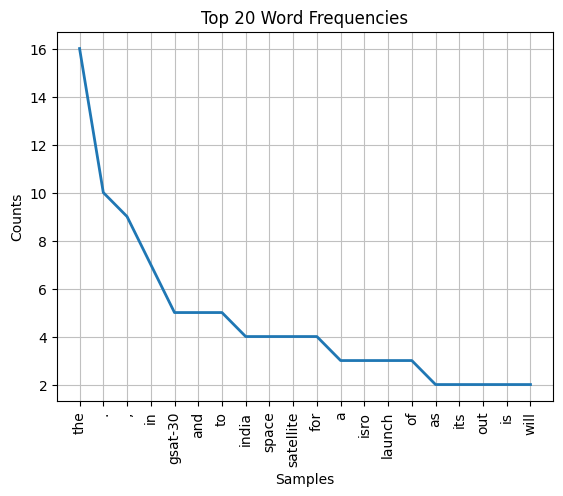

In [19]:
from nltk.probability import FreqDist
import matplotlib.pyplot as plt

fdist = FreqDist(words)  # `words` from previous code
fdist.plot(20, title="Top 20 Word Frequencies")


In [21]:
from nltk.corpus import treebank
from nltk.tag import UnigramTagger,BigramTagger,TrigramTagger
nltk.download('treebank')
traindata=treebank.tagged_sents()[:3000]
testdata=treebank.tagged_sents()[3000:]

to=UnigramTagger(traindata)
t1=BigramTagger(traindata,backoff=to)
t2=TrigramTagger(traindata,backoff=t1)

t2.evaluate(testdata)

[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\saiff\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\treebank.zip.
C:\Users\saiff\AppData\Local\Temp\ipykernel_11400\2011735109.py:11: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  t2.evaluate(testdata)


0.8647096913447011

In [25]:
from nltk.tag import brill,brill_trainer
traindata=treebank.tagged_sents()[:3000]
uni=nltk.UnigramTagger(traindata)
testdata=treebank.tagged_sents()[3000:3555]
# print(dir(brill))
template=brill.fntbl37()

trainer=brill_trainer.BrillTaggerTrainer(uni,templates=template)

tagger=trainer.train(traindata)

tagger.evaluate(testdata)


C:\Users\saiff\AppData\Local\Temp\ipykernel_11400\1212386095.py:12: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  tagger.evaluate(testdata)


0.8781865687451451

In [40]:
from nltk import RegexpTagger

sentence = word_tokenize("The price is $5.99 and the date is 2025-04-08.")
patterns = [
    (r'.*ing',"Date")    ,
    (r'^(The|is)$','det'),
    (r'^\d{4}-\d{2}-\d{2}$','date'),
    (r'.*',"noun"),
]

tagger = RegexpTagger(patterns)
print(tagger.tag(sentence))


[('The', 'det'), ('price', 'noun'), ('is', 'det'), ('$', 'noun'), ('5.99', 'noun'), ('and', 'noun'), ('the', 'noun'), ('date', 'noun'), ('is', 'det'), ('2025-04-08', 'date'), ('.', 'noun')]


LookupError: 
**********************************************************************
  Resource [93mieer[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('ieer')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/ieer[0m

  Searched in:
    - 'C:\\Users\\saiff/nltk_data'
    - 'c:\\Users\\saiff\\Desktop\\NLP\\.venv\\nltk_data'
    - 'c:\\Users\\saiff\\Desktop\\NLP\\.venv\\share\\nltk_data'
    - 'c:\\Users\\saiff\\Desktop\\NLP\\.venv\\lib\\nltk_data'
    - 'C:\\Users\\saiff\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [45]:
from nltk import MaxentClassifier
from nltk.corpus import treebank

train_data = treebank.tagged_sents()[:1500]
test_data = treebank.tagged_sents()[1500:2000]

def pos_features(sentence, i):
    features = {
        'word': sentence[i],
        'is_first': i == 0,
        'is_last': i == len(sentence) - 1,
        'prev_word': '' if i == 0 else sentence[i - 1],
        'next_word': '' if i == len(sentence) - 1 else sentence[i + 1],
        'is_capitalized': sentence[i][0].upper() == sentence[i][0],
        'is_numeric': sentence[i].isdigit()
    }
    return features

featuresets = []
for tagged_sent in train_data:
    words, tags = zip(*tagged_sent)
    for i in range(len(words)):
        featuresets.append((pos_features(words, i), tags[i]))

train_set = featuresets[:1500]
test_set = featuresets[1500:2000]

classifier = MaxentClassifier.train(train_set, max_iter=10)
print("Accuracy:", nltk.classify.accuracy(classifier, test_set))


  ==> Training (10 iterations)

      Iteration    Log Likelihood    Accuracy
      ---------------------------------------
             1          -3.55535        0.005
             2          -1.48079        0.766
             3          -1.08783        0.905
             4          -0.84380        0.979
             5          -0.68214        0.995
             6          -0.57010        0.997
             7          -0.48878        0.999
             8          -0.42737        0.999
             9          -0.37948        0.999
         Final          -0.34115        1.000
Accuracy: 0.636
